In [2]:
import pandas as pd
df = pd.read_json("D:\\datafile\\asset_data_analysis.json", orient = "split")
df.tail()

,date,products,sales,costs
3,2021-11-07,cars,15900,10910
4,2021-12-06,boats,12087,7087
5,2021-12-09,cars,56897,40447
6,2021-11-10,cars,11879,5879
7,2021-12-06,houses,19345,13451


In [4]:
df_copy = df.copy()

df_copy['date'] = pd.to_datetime(df_copy['date'])
df_copy = df.set_index('date', drop = False)
df_copy.head()

,date,products,sales,costs
date,,,,
2021-11-20,2021-11-20,cars,19234,12340
2021-12-12,2021-12-12,boats,87598,67568
2021-12-06,2021-12-06,houses,20989,11999
2021-11-07,2021-11-07,cars,15900,10910
2021-12-06,2021-12-06,boats,12087,7087


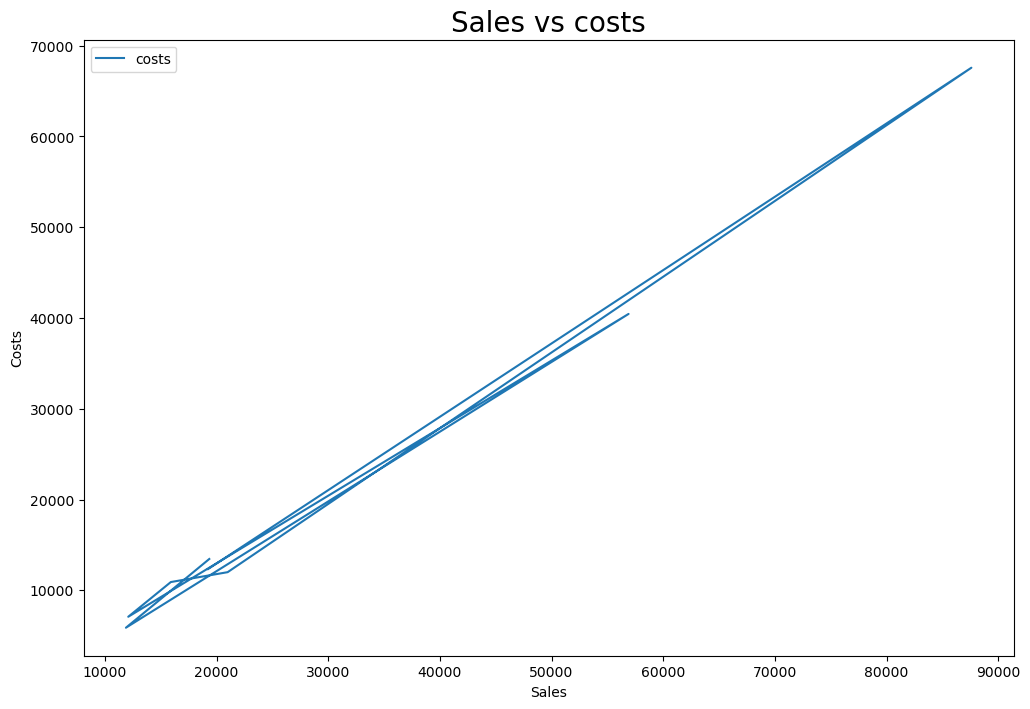

In [7]:
import matplotlib.pyplot as plt

df_copy.plot(x = "sales", y ="costs",kind = "line", figsize =(12, 8))
plt.xlabel("Sales")
plt.ylabel("Costs")
plt.title("Sales vs costs", fontsize = 20)
plt.show()


In [8]:
df2 = df.set_index(['date', 'products'])
df2

,,sales,costs
date,products,,
2021-11-20,cars,19234,12340
2021-12-12,boats,87598,67568
2021-12-06,houses,20989,11999
2021-11-07,cars,15900,10910
2021-12-06,boats,12087,7087
2021-12-09,cars,56897,40447
2021-11-10,cars,11879,5879
2021-12-06,houses,19345,13451


In [9]:
sales_on_12 = df2.loc[(["12-06-21"], "houses"), "sales"].sum()

costs_on_12 = df2.loc[(["12-06-21"], "houses"), "costs"].sum()

profit = sales_on_12 - costs_on_12

print(f"Profit 12 june is {profit}")

Profit 12 june is 14884


In [14]:
def thousand_separator(df, sales, costs):
    df[sales] = df[sales].apply(lambda x: '{:,}'.format(x))
    df[costs] = df[costs].apply(lambda x: '{:,}'.format(x))
    return df
thousand_separator(df, "sales", "costs")    

ValueError: Cannot specify ',' with 's'.